# Predicting U.S Flight Delays Using Machine Learning

## ADS 504 Final Team Project

### Team Members
Christopher Andra, Caly Nguyen, Titus Sun

# Introduction
Flight delays are a common problem in commercial aviation and can affect passengers, airlines, airports, and connecting flight schedules. Delays may result from weather, airport congestion, airline operations, aircraft availability, and earlier disruptions that continue throughout the day. Because many of these factors interact, predicting whether a flight will arrive late can be challenging.

Machine learning can be used to identify patterns in historical flight data and estimate the likelihood of a future delay. However, a realistic prediction should rely only on information that would be available before the flight departs. Using variables recorded after departure could make a model appear more accurate while providing little practical value.

This project uses the 2015 Flight Delays and Cancellations dataset to examine patterns in U.S. domestic flight performance and develop classification models for significant arrival delays. A significant delay is defined as arriving at least 15 minutes after the scheduled arrival time.

# Problem Statement

The goal of this project is to develop and compare machine learning models that predict whether a completed, non-diverted U.S. domestic flight will arrive at least 15 minutes late.

The models will use only information available before departure, including airline, month, day of week, scheduled departure and arrival times, flight distance, scheduled duration, and scheduled base engineered features. Variables recorded after departure will be excluded to prevent data leakage.

Model performance will be evaluated using a time-based validation strategy and metrics including accuracy, precision, recall, F1 score, ROC-AUC, PR-AUC, and confusion matrices. The project also examines whether more complex algorithms provide stronger delay detection than a simpler baseline model.

###Imported Libaries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
!pip install -q --upgrade scikit-learn==1.7.2


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print(os.listdir("/content/drive/MyDrive"))

['Untitled document.gdoc', 'Predictive Model to Detect Fraudulent Insurance Claims.gslides', 'ADS 507 Project.gdoc', 'Netflix Rating Prediction and Recommendation.gslides', 'ADS503 Executive Summary.gslides', 'ADS 503 Final Project Technical Report.gdoc', 'Colab Notebooks', 'flight_delay.zip', 'ADS504_FlightDelay', 'ads504presentation.gslides', 'Gemini Gems', 'ADS504paper.gdoc']


In [5]:
flights_path = "/content/drive/MyDrive/ADS504_FlightDelay/flights.csv"
airports_path = "/content/drive/MyDrive/ADS504_FlightDelay/airports.csv"
airlines_path = "/content/drive/MyDrive/ADS504_FlightDelay/airlines.csv"

flights = pd.read_csv(flights_path, dtype={'TAIL_NUMBER': 'string', 'ORIGIN_AIRPORT': 'string', 'DESTINATION_AIRPORT': 'string'}, low_memory=False)
airports = pd.read_csv(airports_path)
airlines = pd.read_csv(airlines_path)



In [6]:

print("Flights file found:", os.path.exists(flights_path))
print("Airports file found:", os.path.exists(airports_path))
print("Airlines file found:", os.path.exists(airlines_path))

Flights file found: True
Airports file found: True
Airlines file found: True


In [7]:

flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:

airports.head()


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [9]:
airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


# Data Description

The project uses the 2015 Flight Delays and Cancellations dataset from Kaggle. The data are divided into three files:

1. **Flights dataset:** Contains individual domestic flight records, including the date, airline, flight number, origin airport, destination airport, scheduled times, actual times, delay information, distance, cancellation status, and diversion status.

2. **Airports dataset:** Contains descriptive information for the airports represented in the flight data, including airport codes, airport names, cities, states, countries, latitude, and longitude.

3. **Airlines dataset:** Connects airline codes in the flights dataset to the full names of the airlines.

The flights dataset contains 5,819,079 observations and 31 variables. Each observation represents one scheduled domestic flight during 2015.

In [10]:
print("Flights dataset shape:", flights.shape)
print("Airports dataset shape:", airports.shape)
print("Airlines dataset shape:", airlines.shape)

Flights dataset shape: (5819079, 31)
Airports dataset shape: (322, 7)
Airlines dataset shape: (14, 2)


In [11]:
print("Flights columns:")
print(flights.columns.tolist())

print("\nAirports columns:")
print(airports.columns.tolist())

print("\nAirlines columns:")
print(airlines.columns.tolist())

Flights columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

Airports columns:
['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']

Airlines columns:
['IATA_CODE', 'AIRLINE']


In [12]:
print("Flights information:")
flights.info()

print("\nAirports information:")
airports.info()

print("\nAirlines information:")
airlines.info()




Flights information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          string 
 7   ORIGIN_AIRPORT       string 
 8   DESTINATION_AIRPORT  string 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED   

## Exploratory Data Analysis

In [13]:
print("Numeric summary of the flights dataset:")
display(flights.describe().T)

print("\nCategorical summary of the flights dataset:")
display(flights.describe(include=["object"]).T)

print("\nSummary of the airports dataset:")
display(airports.describe(include="all").T)

print("\nSummary of the airlines dataset:")
display(airlines.describe(include="all").T)

Numeric summary of the flights dataset:


,count,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,5819079.0,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
SCHEDULED_DEPARTURE,5819079.0,1329.602470,483.751821,1.0,917.0,1325.0,1730.0,2359.0
DEPARTURE_TIME,5732926.0,1335.204439,496.423260,1.0,921.0,1330.0,1740.0,2400.0
DEPARTURE_DELAY,5732926.0,9.370158,37.080942,-82.0,-5.0,-2.0,7.0,1988.0
TAXI_OUT,5730032.0,16.071662,8.895574,1.0,11.0,14.0,19.0,225.0
WHEELS_OFF,5730032.0,1357.170841,498.009356,1.0,935.0,1343.0,1754.0,2400.0



Categorical summary of the flights dataset:


,count,unique,top,freq
AIRLINE,5819079,14,WN,1261855
CANCELLATION_REASON,89884,4,B,48851



Summary of the airports dataset:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
IATA_CODE,322,322,YUM,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIRPORT,322,322,Yuma International Airport,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CITY,322,308,Portland,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATE,322,54,TX,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRY,322,1,USA,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LATITUDE,319.0,NaN,NaN,NaN,38.981244,8.616736,13.48345,33.65204,39.29761,43.154675,71.28545
LONGITUDE,319.0,NaN,NaN,NaN,-98.378964,21.523492,-176.64603,-110.839385,-93.40307,-82.722995,-64.79856



Summary of the airlines dataset:


,count,unique,top,freq
IATA_CODE,14,14,UA,1
AIRLINE,14,14,United Air Lines Inc.,1


In [14]:
flights_missing= (flights.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

display(flights_missing)

,Missing_Count
CANCELLATION_REASON,5729195
LATE_AIRCRAFT_DELAY,4755640
WEATHER_DELAY,4755640
AIRLINE_DELAY,4755640
AIR_SYSTEM_DELAY,4755640
SECURITY_DELAY,4755640
ELAPSED_TIME,105071
AIR_TIME,105071
ARRIVAL_DELAY,105071
WHEELS_ON,92513


In [15]:
airports_missing = (airports.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print("Missing values in airports dataset:")
display(airports_missing)

Missing values in airports dataset:


,Missing_Count
LONGITUDE,3
LATITUDE,3
IATA_CODE,0
CITY,0
AIRPORT,0
COUNTRY,0
STATE,0


In [16]:
airlines_missing = (airlines.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print("Missing values in airlines dataset:")
display(airlines_missing)

Missing values in airlines dataset:


,Missing_Count
IATA_CODE,0
AIRLINE,0


In [17]:
flights_duplicate_count = flights.duplicated().sum()
airports_duplicate_count = airports.duplicated().sum()
airlines_duplicate_count = airlines.duplicated().sum()

print("Duplicate flight rows:", flights_duplicate_count)
print("Duplicate airport rows:", airports_duplicate_count)
print("Duplicate airline rows:", airlines_duplicate_count)

Duplicate flight rows: 0
Duplicate airport rows: 0
Duplicate airline rows: 0


In [18]:
print("Number of airport rows:", len(airports))
print("Number of unique airport codes:", airports["IATA_CODE"].nunique())

duplicate_airport_codes = airports[airports["IATA_CODE"].duplicated(keep=False)].sort_values("IATA_CODE")

display(duplicate_airport_codes)

Number of airport rows: 322
Number of unique airport codes: 322


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE


In [19]:
print("Number of airline rows:", len(airlines))
print("Number of unique airline codes:", airlines["IATA_CODE"].nunique())

duplicate_airline_codes = airlines[airlines["IATA_CODE"].duplicated(keep=False)].sort_values("IATA_CODE")

display(duplicate_airline_codes)

Number of airline rows: 14
Number of unique airline codes: 14


,IATA_CODE,AIRLINE


In [20]:
display(airlines.sort_values("IATA_CODE").reset_index(drop=True))

,IATA_CODE,AIRLINE
0,AA,American Airlines Inc.
1,AS,Alaska Airlines Inc.
2,B6,JetBlue Airways
3,DL,Delta Air Lines Inc.
4,EV,Atlantic Southeast Airlines
5,F9,Frontier Airlines Inc.
6,HA,Hawaiian Airlines Inc.
7,MQ,American Eagle Airlines Inc.
8,NK,Spirit Air Lines
9,OO,Skywest Airlines Inc.


In [21]:
print("Unique airline codes:")
print(sorted(airlines["IATA_CODE"].dropna().unique()))

print("\nUnique airline names:")
print(sorted(airlines["AIRLINE"].dropna().unique()))

Unique airline codes:
['AA', 'AS', 'B6', 'DL', 'EV', 'F9', 'HA', 'MQ', 'NK', 'OO', 'UA', 'US', 'VX', 'WN']

Unique airline names:
['Alaska Airlines Inc.', 'American Airlines Inc.', 'American Eagle Airlines Inc.', 'Atlantic Southeast Airlines', 'Delta Air Lines Inc.', 'Frontier Airlines Inc.', 'Hawaiian Airlines Inc.', 'JetBlue Airways', 'Skywest Airlines Inc.', 'Southwest Airlines Co.', 'Spirit Air Lines', 'US Airways Inc.', 'United Air Lines Inc.', 'Virgin America']


In [22]:
airports_missing_coordinates = airports[airports["LATITUDE"].isna() | airports["LONGITUDE"].isna()]

display(airports_missing_coordinates)

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
96,ECP,Northwest Florida Beaches International Airport,Panama City,FL,USA,NaN,NaN
234,PBG,Plattsburgh International Airport,Plattsburgh,NY,USA,NaN,NaN
313,UST,Northeast Florida Regional Airport (St. August...,St. Augustine,FL,USA,NaN,NaN


In [23]:
invalid_latitudes = airports[(airports["LATITUDE"] < -90) |  (airports["LATITUDE"] > 90)]

invalid_longitudes = airports[(airports["LONGITUDE"] < -180) | (airports["LONGITUDE"] > 180)]

print("Invalid latitude records:", len(invalid_latitudes))
print("Invalid longitude records:", len(invalid_longitudes))

Invalid latitude records: 0
Invalid longitude records: 0


In [24]:
flight_airline_codes = set(flights["AIRLINE"].dropna().unique())
reference_airline_codes = set(airlines["IATA_CODE"].dropna().unique())

missing_airline_codes = flight_airline_codes - reference_airline_codes
unused_airline_codes = reference_airline_codes - flight_airline_codes

print("Airline codes missing from airlines.csv:", missing_airline_codes)
print("Unused airline codes in airlines.csv:", unused_airline_codes)

Airline codes missing from airlines.csv: set()
Unused airline codes in airlines.csv: set()


In [25]:
flight_origin_codes = set(
    flights["ORIGIN_AIRPORT"].dropna().astype(str).unique()
)

flight_destination_codes = set(
    flights["DESTINATION_AIRPORT"].dropna().astype(str).unique()
)

reference_airport_codes = set(
    airports["IATA_CODE"].dropna().astype(str).unique()
)

missing_origin_codes = flight_origin_codes - reference_airport_codes
missing_destination_codes = flight_destination_codes - reference_airport_codes

print("Number of unmatched origin codes:", len(missing_origin_codes))
print("Number of unmatched destination codes:", len(missing_destination_codes))

print("Sample unmatched origin codes:")
print(sorted(missing_origin_codes)[:20])

print("\nSample unmatched destination codes:")
print(sorted(missing_destination_codes)[:20])

Number of unmatched origin codes: 306
Number of unmatched destination codes: 307
Sample unmatched origin codes:
['10135', '10136', '10140', '10141', '10146', '10154', '10155', '10157', '10158', '10165', '10170', '10185', '10208', '10257', '10268', '10279', '10299', '10333', '10372', '10397']

Sample unmatched destination codes:
['10135', '10136', '10140', '10141', '10146', '10154', '10155', '10157', '10158', '10165', '10170', '10185', '10208', '10257', '10268', '10279', '10299', '10333', '10372', '10397']


In [26]:
unmatched_airport_rows = flights[
    (~flights["ORIGIN_AIRPORT"].astype(str).isin(reference_airport_codes)) |
    (~flights["DESTINATION_AIRPORT"].astype(str).isin(reference_airport_codes))].copy()

unmatched_rows_by_month = (unmatched_airport_rows["MONTH"].value_counts().sort_index().to_frame("Unmatched_Rows"))

display(unmatched_rows_by_month)

,Unmatched_Rows
MONTH,
10,486165


In [27]:
origin_is_three_letters = (flights["ORIGIN_AIRPORT"].astype("string").str.fullmatch(r"[A-Z]{3}", na=False))

origin_is_numeric = (flights["ORIGIN_AIRPORT"].astype("string").str.fullmatch(r"\d+", na=False))

airport_code_format_by_month = pd.DataFrame({"Total_Records": flights.groupby("MONTH").size(),
    "Three_Letter_Origin_Codes": (origin_is_three_letters.groupby(flights["MONTH"]).sum()),
    "Numeric_Origin_Codes": (origin_is_numeric.groupby(flights["MONTH"]).sum())})

display(airport_code_format_by_month)

,Total_Records,Three_Letter_Origin_Codes,Numeric_Origin_Codes
MONTH,,,
1,469968,469968,0
2,429191,429191,0
3,504312,504312,0
4,485151,485151,0
5,496993,496993,0
6,503897,503897,0
7,520718,520718,0
8,510536,510536,0
9,464946,464946,0


In [28]:
print("Last 10 September flights:")
display(flights.loc[flights["MONTH"] == 9, ["MONTH", "AIRLINE", "FLIGHT_NUMBER","ORIGIN_AIRPORT", "DESTINATION_AIRPORT"] ].tail(10))

print("First 10 October flights:")
display(flights.loc[flights["MONTH"] == 10, ["MONTH", "AIRLINE", "FLIGHT_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]].head(10))

Last 10 September flights:


,MONTH,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT
4385702,9,AA,1522,SFO,ORD
4385703,9,B6,8,LAS,FLL
4385704,9,B6,98,DEN,JFK
4385705,9,B6,802,SLC,MCO
4385706,9,B6,745,JFK,PSE
4385707,9,B6,1503,JFK,SJU
4385708,9,UA,1553,LAX,IAH
4385709,9,UA,1696,SEA,IAH
4385710,9,F9,1136,LAS,AUS
4385711,9,F9,300,DEN,TPA


First 10 October flights:


,MONTH,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT
4385712,10,AA,1230,14747,11298
4385713,10,DL,1805,14771,13487
4385714,10,NK,612,12889,13487
4385715,10,AA,260,12892,13303
4385716,10,AA,1982,14771,11057
4385717,10,UA,684,14771,13930
4385718,10,UA,1171,12892,13930
4385719,10,AA,448,14869,11057
4385720,10,AA,2406,12892,11298
4385721,10,DL,1617,12892,13487


### Airport-Code Format Finding

The airport-code comparison found 306 unmatched origin identifiers and 307 unmatched destination identifiers. All 486,165 affected flight records occurred in October. Flights in the other months used three-letter airport codes, while October flights used five-digit numeric airport identifiers.

No records were changed during exploratory analysis. The team will decide during preprocessing whether to convert the October numeric identifiers using an airport lookup table or remove October from the modeling dataset.

In [29]:
flights["FLIGHT_DATE"] = pd.to_datetime(flights[["YEAR", "MONTH", "DAY"]],errors="coerce")

print("Earliest flight date:", flights["FLIGHT_DATE"].min())
print("Latest flight date:", flights["FLIGHT_DATE"].max())
print("Invalid flight dates:", flights["FLIGHT_DATE"].isna().sum())

Earliest flight date: 2015-01-01 00:00:00
Latest flight date: 2015-12-31 00:00:00
Invalid flight dates: 0


In [30]:
monthly_flight_counts = (flights["MONTH"].value_counts().sort_index().rename_axis("Month").to_frame("Flight_Count"))

display(monthly_flight_counts)

,Flight_Count
Month,
1,469968
2,429191
3,504312
4,485151
5,496993
6,503897
7,520718
8,510536
9,464946


### Cancelled and Diverted Flights

In [31]:
print("Cancellation values:")
display(flights["CANCELLED"].value_counts(dropna=False).sort_index().to_frame("Flight_Count"))

print("\nDiversion values:")
display(flights["DIVERTED"].value_counts(dropna=False).sort_index().to_frame("Flight_Count"))

Cancellation values:


,Flight_Count
CANCELLED,
0,5729195
1,89884



Diversion values:


,Flight_Count
DIVERTED,
0,5803892
1,15187


In [32]:
print("Unique CANCELLED values:", sorted(flights["CANCELLED"].unique()))
print("Unique DIVERTED values:", sorted(flights["DIVERTED"].unique()))

Unique CANCELLED values: [np.int64(0), np.int64(1)]
Unique DIVERTED values: [np.int64(0), np.int64(1)]


In [33]:
arrival_delay_missing_summary = (
    flights.loc[flights["ARRIVAL_DELAY"].isna(),["CANCELLED", "DIVERTED"]].value_counts().sort_index().to_frame("Flight_Count"))

display(arrival_delay_missing_summary)

,,Flight_Count
CANCELLED,DIVERTED,
0,1,15187
1,0,89884


### Arrival-Delay Distribution

In [34]:
arrival_delay_summary = (flights["ARRIVAL_DELAY"].describe().to_frame("Arrival_Delay").round(2))

display(arrival_delay_summary)

,Arrival_Delay
count,5714008.00
mean,4.41
std,39.27
min,-87.00
25%,-13.00
50%,-5.00
75%,8.00
max,1971.00


In [35]:
eligible_flights = flights[(flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0) & (flights["ARRIVAL_DELAY"].notna())].copy()

delay_target_counts = (eligible_flights["ARRIVAL_DELAY"].ge(15).value_counts().rename(index={False: "Not significantly delayed",
                                                                          True: "Significantly delayed"}).to_frame("Flight_Count"))

display(delay_target_counts)

,Flight_Count
ARRIVAL_DELAY,
Not significantly delayed,4650569
Significantly delayed,1063439


In [36]:
delay_target_percentages = (eligible_flights["ARRIVAL_DELAY"].ge(15) .value_counts(normalize=True)
    .mul(100).rename(index={False: "Not significantly delayed",True: "Significantly delayed"})
    .round(2).to_frame("Percentage"))

display(delay_target_percentages)

,Percentage
ARRIVAL_DELAY,
Not significantly delayed,81.39
Significantly delayed,18.61


In [37]:
arrival_delay_quantiles = (eligible_flights["ARRIVAL_DELAY"].quantile([0.90, 0.95, 0.99, 0.995, 0.999]).to_frame("Arrival_Delay_Minutes"))

display(arrival_delay_quantiles)

,Arrival_Delay_Minutes
0.900,34.0
0.950,66.0
0.990,167.0
0.995,218.0
0.999,368.0


In [38]:
extreme_delay_counts = pd.DataFrame({"Delay_Threshold": ["At least 60 minutes", "At least 180 minutes","At least 360 minutes",
        "At least 720 minutes"],"Flight_Count": [
        (eligible_flights["ARRIVAL_DELAY"] >= 60).sum(),
        (eligible_flights["ARRIVAL_DELAY"] >= 180).sum(),
        (eligible_flights["ARRIVAL_DELAY"] >= 360).sum(),
        (eligible_flights["ARRIVAL_DELAY"] >= 720).sum() ]})

display(extreme_delay_counts)

,Delay_Threshold,Flight_Count
0,At least 60 minutes,325591
1,At least 180 minutes,47861
2,At least 360 minutes,6146
3,At least 720 minutes,870


In [39]:
most_delayed_flights = (eligible_flights[["FLIGHT_DATE","AIRLINE","FLIGHT_NUMBER","ORIGIN_AIRPORT","DESTINATION_AIRPORT","ARRIVAL_DELAY"]]
    .sort_values("ARRIVAL_DELAY", ascending=False).head(20))

display(most_delayed_flights)

,FLIGHT_DATE,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ARRIVAL_DELAY
337720,2015-01-23,AA,1322,BHM,DFW,1971.0
3412085,2015-08-01,AA,96,RIC,DFW,1898.0
4103531,2015-09-13,AA,1063,SAN,DFW,1665.0
5279939,2015-11-27,AA,2559,DTW,ORD,1638.0
5810811,2015-12-31,AA,2214,ABQ,DFW,1636.0
3100911,2015-07-13,AA,1319,IND,LAX,1636.0
886984,2015-02-28,AA,1312,STL,MIA,1627.0
1278418,2015-03-24,AA,1279,OMA,DFW,1598.0
264495,2015-01-18,AA,224,LAS,LAX,1593.0
949876,2015-03-04,AA,270,HNL,LAX,1576.0


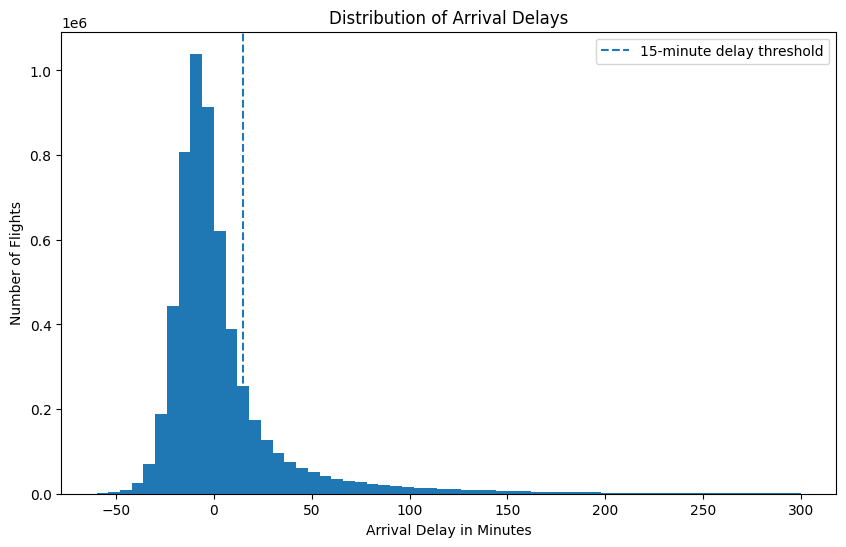

In [40]:
arrival_delay_for_plot = eligible_flights[eligible_flights["ARRIVAL_DELAY"].between(-60, 300)]

plt.figure(figsize=(10, 6))

plt.hist(arrival_delay_for_plot["ARRIVAL_DELAY"], bins=60)

plt.axvline(15,linestyle="--",label="15-minute delay threshold")

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("Number of Flights")
plt.legend()
plt.show()

The histogram shows that most completed flights arrived close to their scheduled arrival time, with many flights arriving slightly early. The distribution is right-skewed because a smaller number of flights experienced much longer delays. The dashed line marks the 15-minute threshold used to define a significant arrival delay.

### Significant Delay Rate by Month

In [41]:
eligible_flights["SIGNIFICANT_DELAY"] = (eligible_flights["ARRIVAL_DELAY"] >= 15).astype(int)

delay_rate_by_month = (eligible_flights.groupby("MONTH")["SIGNIFICANT_DELAY"]
    .mean().mul(100).round(2).to_frame("Significant_Delay_Percentage"))

display(delay_rate_by_month)

,Significant_Delay_Percentage
MONTH,
1,21.00
2,23.35
3,19.40
4,17.16
5,18.31
6,23.48
7,20.92
8,18.67
9,13.00


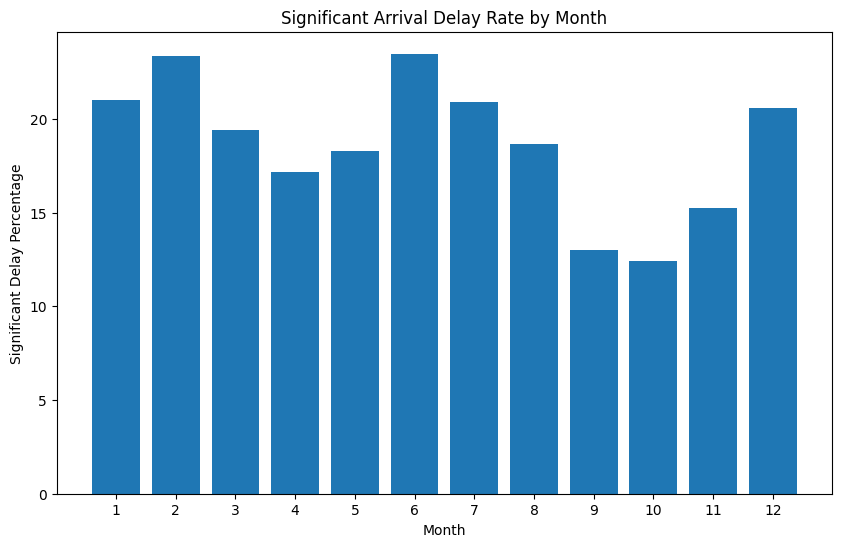

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(delay_rate_by_month.index,delay_rate_by_month["Significant_Delay_Percentage"])

plt.title("Significant Arrival Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Significant Delay Percentage")
plt.xticks(range(1, 13))
plt.show()

### Significant Delay Rate by Airline

In [43]:
delay_rate_by_airline = (eligible_flights.groupby("AIRLINE")["SIGNIFICANT_DELAY"].agg(Flight_Count="count",
        Significant_Delay_Percentage="mean"))

delay_rate_by_airline["Significant_Delay_Percentage"] = (delay_rate_by_airline["Significant_Delay_Percentage"]
    .mul(100).round(2))

delay_rate_by_airline = delay_rate_by_airline.sort_values("Significant_Delay_Percentage",ascending=False)

display(delay_rate_by_airline)

,Flight_Count,Significant_Delay_Percentage
AIRLINE,,
NK,115193,29.71
F9,90090,26.16
B6,262042,22.58
MQ,278791,21.72
UA,507762,20.62
EV,554752,19.68
VX,61248,19.23
WN,1242403,19.05
US,194223,18.82


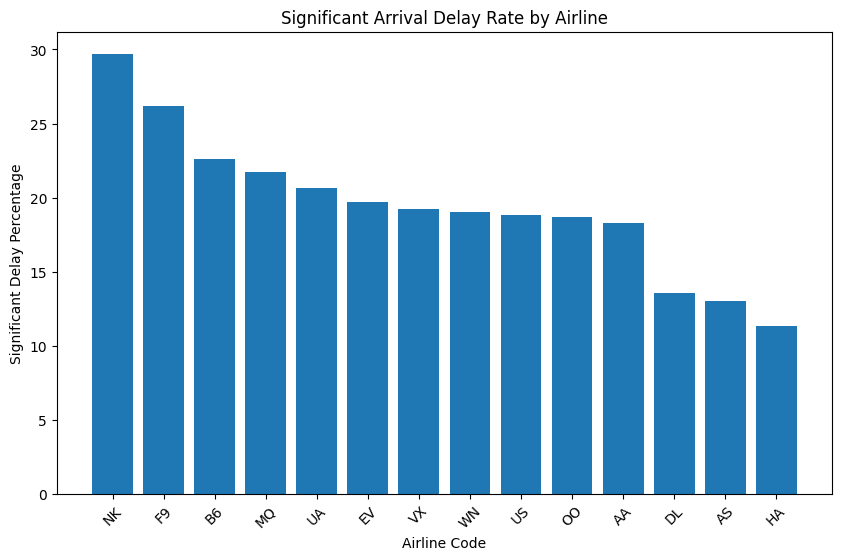

In [44]:
plt.figure(figsize=(10, 6))
plt.bar(delay_rate_by_airline.index, delay_rate_by_airline["Significant_Delay_Percentage"])
plt.title("Significant Arrival Delay Rate by Airline")
plt.xlabel("Airline Code")
plt.ylabel("Significant Delay Percentage")
plt.xticks(rotation=45)
plt.show()

### Significant Delay Rate by Day of Week

In [45]:
delay_rate_by_day = (eligible_flights.groupby("DAY_OF_WEEK")["SIGNIFICANT_DELAY"]
    .mean().mul(100).round(2).to_frame("Significant_Delay_Percentage"))

display(delay_rate_by_day)

,Significant_Delay_Percentage
DAY_OF_WEEK,
1,19.75
2,18.27
3,18.22
4,20.01
5,19.20
6,15.99
7,18.31


In [46]:
day_labels = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

delay_rate_by_day.index = delay_rate_by_day.index.map(day_labels)

display(delay_rate_by_day)

,Significant_Delay_Percentage
DAY_OF_WEEK,
Monday,19.75
Tuesday,18.27
Wednesday,18.22
Thursday,20.01
Friday,19.20
Saturday,15.99
Sunday,18.31


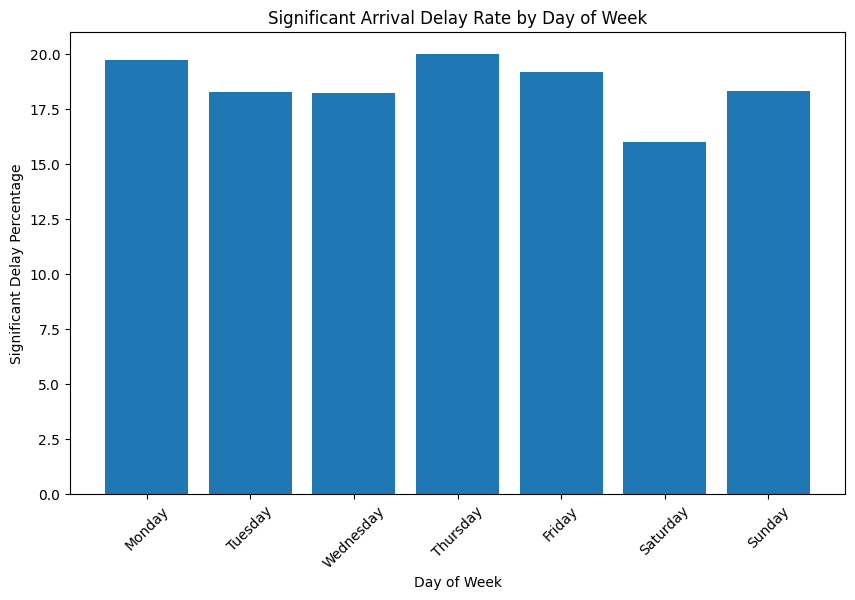

In [47]:
plt.figure(figsize=(10, 6))
plt.bar(delay_rate_by_day.index,delay_rate_by_day["Significant_Delay_Percentage"])

plt.title("Significant Arrival Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Significant Delay Percentage")
plt.xticks(rotation=45)
plt.show()

### Significant Delay Rate by Scheduled Departure Hour

In [48]:
eligible_flights["SCHEDULED_DEPARTURE_HOUR"] = (eligible_flights["SCHEDULED_DEPARTURE"] // 100)

print(sorted(eligible_flights["SCHEDULED_DEPARTURE_HOUR"].dropna().unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [49]:
delay_rate_by_hour = (eligible_flights.groupby("SCHEDULED_DEPARTURE_HOUR")["SIGNIFICANT_DELAY"]
    .agg(Flight_Count="count",Significant_Delay_Percentage="mean"))

delay_rate_by_hour["Significant_Delay_Percentage"] = (delay_rate_by_hour["Significant_Delay_Percentage"].mul(100).round(2))

display(delay_rate_by_hour)

,Flight_Count,Significant_Delay_Percentage
SCHEDULED_DEPARTURE_HOUR,,
0,14504,15.95
1,5091,18.78
2,1383,17.14
3,767,17.73
4,526,20.15
5,115647,7.27
6,398508,9.03
7,387719,11.21
8,374828,12.90


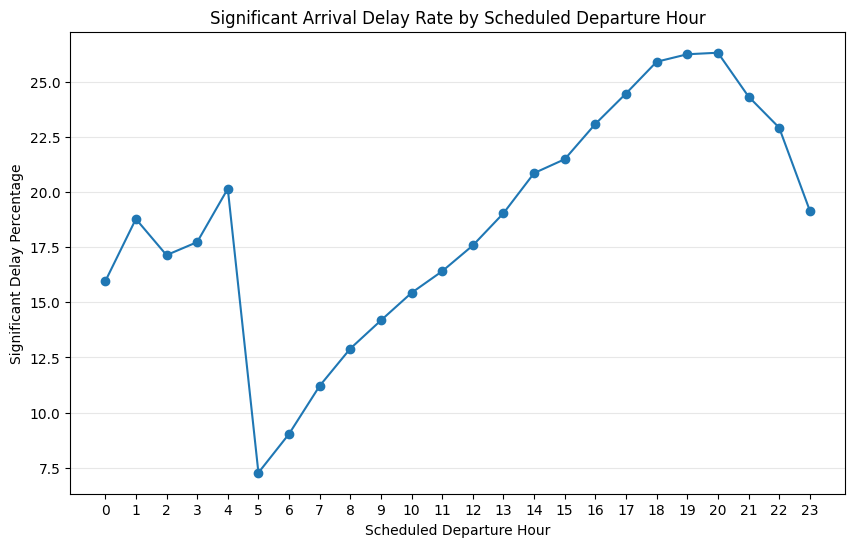

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(delay_rate_by_hour.index,delay_rate_by_hour["Significant_Delay_Percentage"],marker="o")

plt.title("Significant Arrival Delay Rate by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Significant Delay Percentage")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.show()

### Significant Delay Rate by Distance Group

In [51]:
distance_bins = [0, 500, 1000, 1500, 2500, float("inf")]

distance_labels = [
    "Under 500 miles",
    "500–999 miles",
    "1,000–1,499 miles",
    "1,500–2,499 miles",
    "2,500 miles or more"
]

eligible_flights["DISTANCE_GROUP"] = pd.cut(eligible_flights["DISTANCE"],bins=distance_bins, labels=distance_labels, right=False)

In [52]:
delay_rate_by_distance = (eligible_flights
    .groupby("DISTANCE_GROUP", observed=False)["SIGNIFICANT_DELAY"]
    .agg(Flight_Count="count",Significant_Delay_Percentage="mean"))

delay_rate_by_distance["Significant_Delay_Percentage"] = (
    delay_rate_by_distance["Significant_Delay_Percentage"].mul(100).round(2))

display(delay_rate_by_distance)

,Flight_Count,Significant_Delay_Percentage
DISTANCE_GROUP,,
Under 500 miles,2073950,18.21
500–999 miles,2015991,18.65
"1,000–1,499 miles",845177,19.72
"1,500–2,499 miles",659502,18.32
"2,500 miles or more",119388,18.72


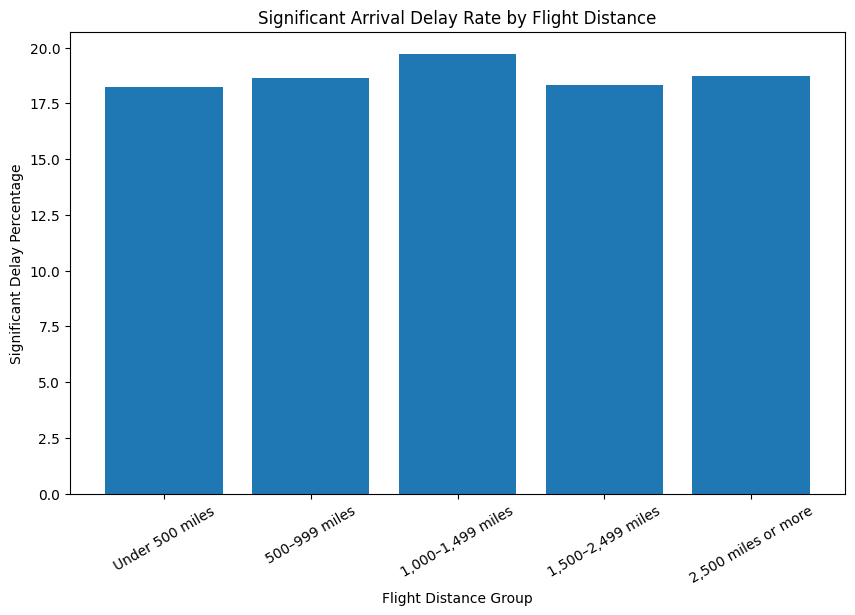

In [53]:
plt.figure(figsize=(10, 6))
plt.bar(delay_rate_by_distance.index.astype(str),delay_rate_by_distance["Significant_Delay_Percentage"])

plt.title("Significant Arrival Delay Rate by Flight Distance")
plt.xlabel("Flight Distance Group")
plt.ylabel("Significant Delay Percentage")
plt.xticks(rotation=30)
plt.show()

### Significant Delay Rate by Scheduled Arrival Hour

In [54]:
eligible_flights["SCHEDULED_ARRIVAL_HOUR"] = (eligible_flights["SCHEDULED_ARRIVAL"] // 100)

print(sorted( eligible_flights["SCHEDULED_ARRIVAL_HOUR"].dropna().unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [55]:
delay_rate_by_arrival_hour = (eligible_flights.groupby("SCHEDULED_ARRIVAL_HOUR")["SIGNIFICANT_DELAY"].agg(
        Flight_Count="count",Significant_Delay_Percentage="mean"))

delay_rate_by_arrival_hour["Significant_Delay_Percentage"] = ( delay_rate_by_arrival_hour["Significant_Delay_Percentage"].mul(100).round(2))

display(delay_rate_by_arrival_hour)

,Flight_Count,Significant_Delay_Percentage
SCHEDULED_ARRIVAL_HOUR,,
0,70062,26.08
1,12539,25.52
2,3038,21.03
3,1495,27.76
4,6126,18.15
5,39519,17.21
6,88875,11.01
7,188970,9.12
8,273768,10.11


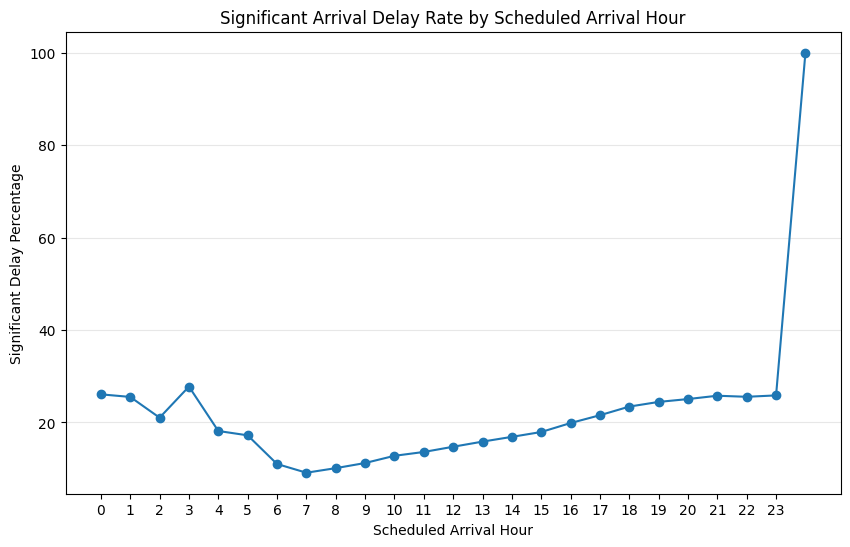

In [56]:
plt.figure(figsize=(10, 6))

plt.plot( delay_rate_by_arrival_hour.index, delay_rate_by_arrival_hour["Significant_Delay_Percentage"],
    marker="o")

plt.title("Significant Arrival Delay Rate by Scheduled Arrival Hour")
plt.xlabel("Scheduled Arrival Hour")
plt.ylabel("Significant Delay Percentage")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.show()

### Significant Delay Rate by Scheduled Flight Duration

In [57]:
duration_bins = [0, 60, 120, 180, 240, 360, float("inf")]

duration_labels = [
    "Under 1 hour",
    "1–2 hours",
    "2–3 hours",
    "3–4 hours",
    "4–6 hours",
    "6 hours or more"]

eligible_flights["SCHEDULED_DURATION_GROUP"] = pd.cut(eligible_flights["SCHEDULED_TIME"],bins=duration_bins,
    labels=duration_labels, right=False)

In [58]:
delay_rate_by_duration = (eligible_flights.groupby("SCHEDULED_DURATION_GROUP",observed=False )["SIGNIFICANT_DELAY"]
    .agg(Flight_Count="count", Significant_Delay_Percentage="mean"))

delay_rate_by_duration["Significant_Delay_Percentage"] = (delay_rate_by_duration["Significant_Delay_Percentage"].mul(100).round(2))

display(delay_rate_by_duration)

,Flight_Count,Significant_Delay_Percentage
SCHEDULED_DURATION_GROUP,,
Under 1 hour,297623,16.62
1–2 hours,2432753,18.30
2–3 hours,1671889,19.26
3–4 hours,661537,19.29
4–6 hours,557888,18.06
6 hours or more,92318,20.07


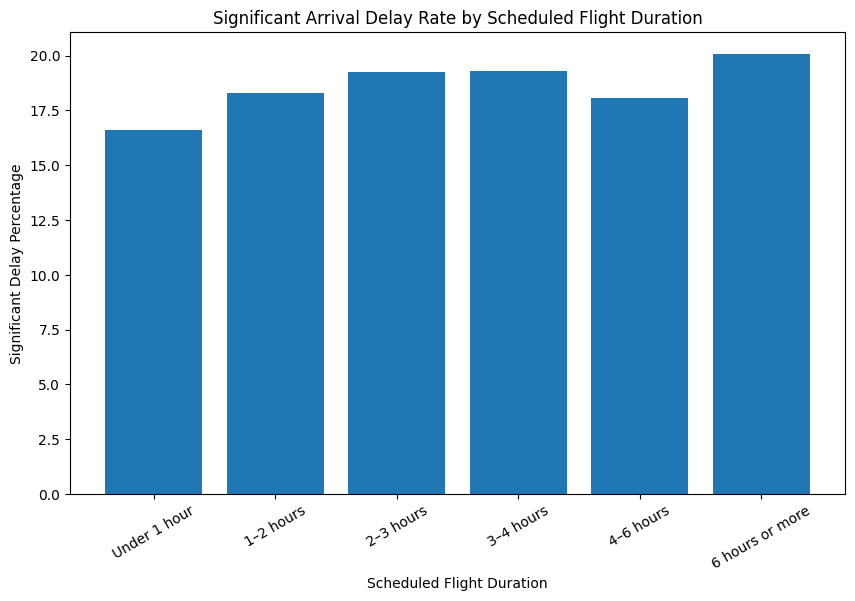

In [59]:
plt.figure(figsize=(10, 6))
plt.bar( delay_rate_by_duration.index.astype(str),delay_rate_by_duration["Significant_Delay_Percentage"])

plt.title("Significant Arrival Delay Rate by Scheduled Flight Duration")
plt.xlabel("Scheduled Flight Duration")
plt.ylabel("Significant Delay Percentage")
plt.xticks(rotation=30)
plt.show()

### Correlation Between Numeric Pre-Departure Features

In [60]:
correlation_columns = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE_HOUR",
    "SCHEDULED_ARRIVAL_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "SIGNIFICANT_DELAY"]

correlation_matrix = (eligible_flights[correlation_columns].corr().round(2))

display(correlation_matrix)

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE_HOUR,SCHEDULED_ARRIVAL_HOUR,SCHEDULED_TIME,DISTANCE,SIGNIFICANT_DELAY
MONTH,1.00,0.01,-0.01,-0.00,-0.01,0.01,0.01,-0.04
DAY,0.01,1.00,0.00,-0.00,-0.00,0.00,0.00,-0.01
DAY_OF_WEEK,-0.01,0.00,1.00,0.01,0.01,0.01,0.02,-0.01
SCHEDULED_DEPARTURE_HOUR,-0.00,-0.00,0.01,1.00,0.70,-0.02,-0.01,0.14
SCHEDULED_ARRIVAL_HOUR,-0.01,-0.00,0.01,0.70,1.00,0.03,0.03,0.12
SCHEDULED_TIME,0.01,0.00,0.01,-0.02,0.03,1.00,0.98,0.01
DISTANCE,0.01,0.00,0.02,-0.01,0.03,0.98,1.00,0.01
SIGNIFICANT_DELAY,-0.04,-0.01,-0.01,0.14,0.12,0.01,0.01,1.00


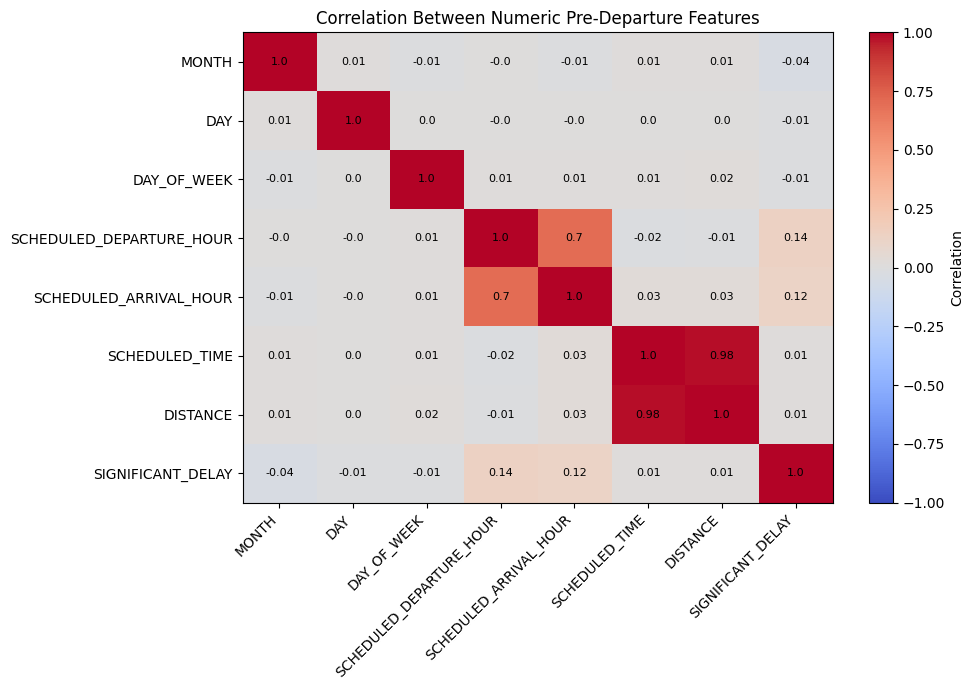

In [61]:
plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_columns)), correlation_columns)

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        plt.text(column, row,  correlation_matrix.iloc[row, column], ha="center", va="center", fontsize=8 )

plt.title("Correlation Between Numeric Pre-Departure Features")
plt.tight_layout()
plt.show()

The numeric pre-departure variables showed weak individual linear relationships with significant arrival delay. Scheduled departure hour and scheduled arrival hour had the strongest correlations with the target, although both correlations were still relatively small. Scheduled flight time and distance were highly correlated with each other, indicating that they contain similar information. These results suggest that useful delay patterns may depend more on nonlinear relationships, categorical variables, and interactions between features than on strong individual numeric correlations.

to help with october inconsitencies file is from bureau transporation of statistics https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FLL&QO_fu146_anzr=

Columns description from website:

AirportSeqID- An identification number assigned by US DOT to identify a unique airport at a given point of time. Airport attributes, such as airport name or coordinates, may change over time.

AirportID - An identification number assigned by US DOT to identify a unique airport. Use this field for airport analysis across a range of years because an airport can change its airport code and airport codes can be reused.

Airport - 	A three character alpha-numeric code issued by the U.S. Department of Transportation which is the official designation of the airport. The airport code is not always unique to a specific airport because airport codes can change or can be reused.

AirportName -	Airport Name

AirportCityName	- Airport City Name with either U.S. State or Country

AirportStateName -	State Name for the Physical Location of the Airport

AirportStateCode- State Abbreviation for the Physical Location of the Airport

AirportStartDate- Start Date of Airport Attributes

AirportEndDate	- End Date of Airport Attributes (Active = NULL)

AirportIsClosed	- Indicates if the airport is closed (1 = Yes). If yes, the airport is closed is on the AirportEndDate.	Get Lookup Table

AirportIsLatest	- Indicates if this row contains the latest attributes for the Airport (1 = Yes)


In [62]:
master_airport_path = "/content/drive/MyDrive/ADS504_FlightDelay/T_MASTER_CORD.csv"
master_airports = pd.read_csv(master_airport_path)

master_airports.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,AIRPORT_SEQ_ID,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,DISPLAY_AIRPORT_CITY_NAME_FULL,AIRPORT_STATE_NAME,AIRPORT_STATE_CODE,AIRPORT_START_DATE,AIRPORT_THRU_DATE,AIRPORT_IS_CLOSED,AIRPORT_IS_LATEST
0,1000101,10001,01A,Afognak Lake Airport,"Afognak Lake, AK",Alaska,AK,7/1/2007 12:00:00 AM,NaN,0,1
1,1000301,10003,03A,Bear Creek Mining Strip,"Granite Mountain, AK",Alaska,AK,7/1/2007 12:00:00 AM,NaN,0,1
2,1000401,10004,04A,Lik Mining Camp,"Lik, AK",Alaska,AK,7/1/2007 12:00:00 AM,NaN,0,1
3,1000501,10005,05A,Little Squaw Airport,"Little Squaw, AK",Alaska,AK,8/1/2007 12:00:00 AM,NaN,0,1
4,1000601,10006,06A,Kizhuyak Bay,"Kizhuyak, AK",Alaska,AK,10/1/2007 12:00:00 AM,NaN,0,1


In [63]:
known_airports = master_airports[master_airports["AIRPORT"].isin(["LAX", "JFK", "ATL", "ORD", "SFO"])][[
    "AIRPORT_ID",
    "AIRPORT",
    "DISPLAY_AIRPORT_NAME",
    "DISPLAY_AIRPORT_CITY_NAME_FULL"
]]

known_airports

,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,DISPLAY_AIRPORT_CITY_NAME_FULL
1042,10397,ATL,Atlanta Municipal,"Atlanta, GA"
1043,10397,ATL,William B. Hartsfield Atlanta International,"Atlanta, GA"
1044,10397,ATL,Hartsfield-Jackson Atlanta International,"Atlanta, GA"
1045,10397,ATL,Hartsfield-Jackson Atlanta International,"Atlanta, GA"
1046,10397,ATL,Hartsfield-Jackson Atlanta International,"Atlanta, GA"
1047,10397,ATL,Hartsfield-Jackson Atlanta International,"Atlanta, GA"
1048,10397,ATL,Hartsfield-Jackson Atlanta International,"Atlanta, GA"
1049,10397,ATL,Hartsfield-Jackson Atlanta International,"Atlanta, GA"
7548,12478,JFK,John F. Kennedy International,"New York, NY"
7549,12478,JFK,John F. Kennedy International,"New York, NY"


In [64]:
airport_id_code_counts = (master_airports.groupby("AIRPORT_ID")["AIRPORT"].nunique().sort_values(ascending=False))

airport_id_code_counts.head(10)

,AIRPORT
AIRPORT_ID,
15968,4
15950,3
16334,3
13471,2
15522,2
10590,2
16866,2
10143,2
13986,2


In [65]:
(airport_id_code_counts > 1).sum()

np.int64(82)

In [66]:
october_flights = flights[flights["MONTH"] == 10].copy()

october_ids = set(pd.concat([october_flights["ORIGIN_AIRPORT"], october_flights["DESTINATION_AIRPORT"]]).dropna().astype(str).unique())

lookup_ids = set(master_airports["AIRPORT_ID"].dropna().astype(int).astype(str).unique())

missing_october_ids = october_ids - lookup_ids

print("Unique October airport IDs:", len(october_ids))
print("October IDs found in lookup:", len(october_ids & lookup_ids))
print("October IDs missing from lookup:", len(missing_october_ids))
print("Missing IDs:", sorted(missing_october_ids)[:20])

Unique October airport IDs: 307
October IDs found in lookup: 307
October IDs missing from lookup: 0
Missing IDs: []


In [67]:
ambiguous_ids = airport_id_code_counts[airport_id_code_counts > 1].index

ambiguous_october_ids = sorted(set(map(int, october_ids)) & set(ambiguous_ids))

print("Ambiguous airport IDs used in October:", len(ambiguous_october_ids))
print(ambiguous_october_ids)

Ambiguous airport IDs used in October: 3
[10423, 10821, 11013]


In [68]:
ambiguous_october_mappings = (master_airports[master_airports["AIRPORT_ID"].isin(ambiguous_october_ids)]
    [[  "AIRPORT_ID",
        "AIRPORT",
        "DISPLAY_AIRPORT_NAME",
        "DISPLAY_AIRPORT_CITY_NAME_FULL",
       "AIRPORT_STATE_CODE"   ]]
    .drop_duplicates().sort_values(["AIRPORT_ID", "AIRPORT"]))

ambiguous_october_mappings

,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,DISPLAY_AIRPORT_CITY_NAME_FULL,AIRPORT_STATE_CODE
1135,10423,AUS,Austin - Bergstrom International,"Austin, TX",TX
1134,10423,BSM,Austin - Bergstrom International,"Austin, TX",TX
2493,10821,BAL,Friendship International,"Baltimore, MD",MD
2494,10821,BWI,Baltimore/Washington International,"Baltimore, MD",MD
2495,10821,BWI,Baltimore/Washington International Thurgood Ma...,"Baltimore, MD",MD
3132,11013,CIU,Chippewa County International,"Sault Ste. Marie, MI",MI
3131,11013,INR,Kincheloe AFB,"Sault Ste. Marie, MI",MI


In [69]:
master_airports["AIRPORT_START_DATE"] = pd.to_datetime(master_airports["AIRPORT_START_DATE"], errors="coerce")

master_airports["AIRPORT_THRU_DATE"] = pd.to_datetime( master_airports["AIRPORT_THRU_DATE"], errors="coerce")

/tmp/ipykernel_28326/4237912593.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  master_airports["AIRPORT_START_DATE"] = pd.to_datetime(master_airports["AIRPORT_START_DATE"], errors="coerce")
/tmp/ipykernel_28326/4237912593.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  master_airports["AIRPORT_THRU_DATE"] = pd.to_datetime( master_airports["AIRPORT_THRU_DATE"], errors="coerce")


In [70]:
october_reference_date = pd.Timestamp("2015-10-01")

airport_lookup_2015 = master_airports[(master_airports["AIRPORT_START_DATE"].isna()
        | (master_airports["AIRPORT_START_DATE"] <= october_reference_date)) &
    ( master_airports["AIRPORT_THRU_DATE"].isna() | (master_airports["AIRPORT_THRU_DATE"] >= october_reference_date))].copy()

In [71]:
print("Rows active in October 2015:", len(airport_lookup_2015))
print("Unique airport IDs:", airport_lookup_2015["AIRPORT_ID"].nunique())

active_code_counts = (airport_lookup_2015.groupby("AIRPORT_ID")["AIRPORT"].nunique())

print( "Airport IDs with multiple active codes:", (active_code_counts > 1).sum())

Rows active in October 2015: 6187
Unique airport IDs: 6187
Airport IDs with multiple active codes: 0


In [72]:
airport_lookup_2015[airport_lookup_2015["AIRPORT_ID"].isin([10423, 10821, 11013])][
    [
        "AIRPORT_SEQ_ID",
        "AIRPORT_ID",
        "AIRPORT",
        "DISPLAY_AIRPORT_NAME",
        "AIRPORT_START_DATE",
        "AIRPORT_THRU_DATE",
        "AIRPORT_IS_CLOSED"
    ]]

,AIRPORT_SEQ_ID,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,AIRPORT_START_DATE,AIRPORT_THRU_DATE,AIRPORT_IS_CLOSED
1135,1042302,10423,AUS,Austin - Bergstrom International,1999-06-01,NaT,0
2495,1082103,10821,BWI,Baltimore/Washington International Thurgood Ma...,2005-10-01,2016-01-31,0
3133,1101303,11013,CIU,Chippewa County International,2011-07-01,2025-06-30,0


In [73]:
# checking septemeber to make sure airport matches airport ID
september_flights = flights[flights["MONTH"] == 9].copy()

In [74]:
id_to_code = (airport_lookup_2015.set_index("AIRPORT_ID")["AIRPORT"].to_dict())

code_to_id = (airport_lookup_2015.drop_duplicates("AIRPORT").set_index("AIRPORT")["AIRPORT_ID"].to_dict())

In [75]:
september_test = september_flights[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]].copy()

september_test["ORIGIN_ID_TEST"] = (september_test["ORIGIN_AIRPORT"].map(code_to_id))


september_test["DESTINATION_ID_TEST"] = ( september_test["DESTINATION_AIRPORT"].map(code_to_id))

september_test["ORIGIN_CODE_RECOVERED"] = (september_test["ORIGIN_ID_TEST"].map(id_to_code))

september_test["DESTINATION_CODE_RECOVERED"] = ( september_test["DESTINATION_ID_TEST"].map(id_to_code))

In [76]:
origin_matches = (september_test["ORIGIN_AIRPORT"] == september_test["ORIGIN_CODE_RECOVERED"])

destination_matches = (september_test["DESTINATION_AIRPORT"] == september_test["DESTINATION_CODE_RECOVERED"])

print("Origin codes matching:", origin_matches.mean())
print("Destination codes matching:", destination_matches.mean())

Origin codes matching: 1.0
Destination codes matching: 1.0


In [77]:
print( "September origin codes missing from lookup:", september_test["ORIGIN_ID_TEST"].isna().sum())

print("September destination codes missing from lookup:", september_test["DESTINATION_ID_TEST"].isna().sum())

September origin codes missing from lookup: 0
September destination codes missing from lookup: 0


In [78]:
september_mismatches = september_test[(~origin_matches) | (~destination_matches)]

september_mismatches.head(20)

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ORIGIN_ID_TEST,DESTINATION_ID_TEST,ORIGIN_CODE_RECOVERED,DESTINATION_CODE_RECOVERED


# Data Preprocessing and Feature Engineering

## Caly's Work: Cleaning, Airport Codes, and Final Modeling Data

**Where this section goes:** Run it after the original files and `T_MASTER_CORD.csv` have been loaded.

**What this section does:**

1. Makes a safe copy of the flight data.
2. Resolves October's numeric airport IDs.
3. Removes cancelled, diverted, and unusable records.
4. Creates features using only information available before departure.
5. Produces a clean `final_modeling_data` table.
6. Builds a simple Scikit-Learn preprocessing pipeline.

> **Important:** The target is created from `ARRIVAL_DELAY`, but `ARRIVAL_DELAY` is removed from the final feature table so the model cannot use future information.


### Step 1 — Make a working copy and standardize the important text fields

This keeps the original `flights` DataFrame unchanged. Converting the airport columns to pandas string type also prevents a mixture of integers and text from causing matching problems.


In [79]:
# Start all cleaning from a copy so the raw data stays unchanged
flights_clean = flights.copy()

text_columns = ["AIRLINE", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

for column in text_columns:
    if column in flights_clean.columns:
        flights_clean[column] = flights_clean[column].astype("string").str.strip()

# Recreate the date in case this section is run independently
flights_clean["FLIGHT_DATE"] = pd.to_datetime(
    flights_clean[["YEAR", "MONTH", "DAY"]],
    errors="coerce"
)

print("Working-copy shape:", flights_clean.shape)
print(flights_clean[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]].dtypes)


Working-copy shape: (5819079, 32)
ORIGIN_AIRPORT         string[python]
DESTINATION_AIRPORT    string[python]
dtype: object


### Step 2 — Build one October 2015 airport-ID lookup

The BTS file may contain multiple historical rows for the same airport ID. The code first keeps rows active on **October 1, 2015**, then keeps the row with the most recent start date for each airport ID. This gives one deterministic three-character code per ID.

The validation lines are intentionally strict. They stop the notebook if an October ID cannot be resolved instead of silently producing missing airport codes.


In [80]:
# Build a one row per airport ID lookup active in October 2015
master_lookup = master_airports.copy()

master_lookup["AIRPORT_ID"] = pd.to_numeric(master_lookup["AIRPORT_ID"], errors="coerce")
master_lookup["AIRPORT_START_DATE"] = pd.to_datetime(
    master_lookup["AIRPORT_START_DATE"], errors="coerce"
)
master_lookup["AIRPORT_THRU_DATE"] = pd.to_datetime(
    master_lookup["AIRPORT_THRU_DATE"], errors="coerce"
)

reference_date = pd.Timestamp("2015-10-01")

active_october_lookup = master_lookup[
    (master_lookup["AIRPORT_START_DATE"].isna() |
     (master_lookup["AIRPORT_START_DATE"] <= reference_date)) &
    (master_lookup["AIRPORT_THRU_DATE"].isna() |
     (master_lookup["AIRPORT_THRU_DATE"] >= reference_date))
].copy()

# If an ID still has more than one active row, use the row with the latest start date.
active_october_lookup = (
    active_october_lookup
    .sort_values(["AIRPORT_ID", "AIRPORT_START_DATE"])
    .drop_duplicates(subset="AIRPORT_ID", keep="last")
)

id_to_airport_code = (
    active_october_lookup
    .dropna(subset=["AIRPORT_ID", "AIRPORT"])
    .assign(AIRPORT_ID=lambda x: x["AIRPORT_ID"].astype(int).astype(str))
    .set_index("AIRPORT_ID")["AIRPORT"]
    .astype("string")
    .str.strip()
    .to_dict()
)

print("Airport IDs available in October lookup:", len(id_to_airport_code))


Airport IDs available in October lookup: 6187


### Step 3 — Convert numeric airport IDs while leaving valid three-letter codes unchanged

The helper function below is reusable for both origin and destination. It checks each value:

- Three letters, such as `DFW` → keep it.
- Numeric ID, such as `11298` → map it through the BTS lookup.
- Anything else → return missing so validation catches it.


In [81]:
# Reusable airport code cleaning function
def resolve_airport_code(value, lookup):
    if pd.isna(value):
        return pd.NA

    value = str(value).strip().upper()

    if len(value) == 3 and value.isalpha():
        return value

    if value.isdigit():
        return lookup.get(value, pd.NA)

    return pd.NA

for column in ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]:
    flights_clean[column] = flights_clean[column].map(
        lambda value: resolve_airport_code(value, id_to_airport_code)
    ).astype("string")

print("Airport conversion complete.")


Airport conversion complete.


### Step 4 — Validate the airport correction

Do not skip this cell.


In [82]:
# Validation checks for the airport-code repair.
airport_reference_codes = set(
    airports["IATA_CODE"].dropna().astype("string").str.strip().str.upper()
)

origin_numeric_remaining = flights_clean["ORIGIN_AIRPORT"].str.fullmatch(r"\d+", na=False).sum()
destination_numeric_remaining = flights_clean["DESTINATION_AIRPORT"].str.fullmatch(r"\d+", na=False).sum()

invalid_origin_format = (~flights_clean["ORIGIN_AIRPORT"].str.fullmatch(r"[A-Z]{3}", na=False)).sum()
invalid_destination_format = (~flights_clean["DESTINATION_AIRPORT"].str.fullmatch(r"[A-Z]{3}", na=False)).sum()

unmatched_origin_codes = set(flights_clean["ORIGIN_AIRPORT"].dropna()) - airport_reference_codes
unmatched_destination_codes = set(flights_clean["DESTINATION_AIRPORT"].dropna()) - airport_reference_codes

print("Numeric origin IDs remaining:", origin_numeric_remaining)
print("Numeric destination IDs remaining:", destination_numeric_remaining)
print("Invalid origin formats:", invalid_origin_format)
print("Invalid destination formats:", invalid_destination_format)
print("Origin codes absent from airports.csv:", sorted(unmatched_origin_codes)[:20])
print("Destination codes absent from airports.csv:", sorted(unmatched_destination_codes)[:20])

assert origin_numeric_remaining == 0, "Some numeric origin airport IDs were not converted."
assert destination_numeric_remaining == 0, "Some numeric destination airport IDs were not converted."
assert invalid_origin_format == 0, "Some origin values are missing or not three-letter codes."
assert invalid_destination_format == 0, "Some destination values are missing or not three-letter codes."


Numeric origin IDs remaining: 0
Numeric destination IDs remaining: 0
Invalid origin formats: 0
Invalid destination formats: 0
Origin codes absent from airports.csv: []
Destination codes absent from airports.csv: []


> **Why the last two unmatched-code lists may not be empty:** `airports.csv` and the BTS master table are different reference sources. A correctly resolved BTS code can still be absent from the smaller Kaggle airport reference file. Review those lists before deciding to drop anything; do not automatically delete valid BTS codes.


### Step 5 — Clean the modeling population

The model is intended to predict arrival delay for completed, non-diverted flights. Therefore, cancelled flights, diverted flights, and records without an arrival delay are excluded. The six missing scheduled-duration rows are also removed because that field is required before departure.


In [83]:
# Keep only records that have a meaningful arrival delay outcome
rows_before = len(flights_clean)

flights_clean = flights_clean[
    (flights_clean["CANCELLED"] == 0) &
    (flights_clean["DIVERTED"] == 0) &
    (flights_clean["ARRIVAL_DELAY"].notna())
].copy()

required_before_departure = [
    "AIRLINE", "MONTH", "DAY", "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE", "SCHEDULED_ARRIVAL",
    "SCHEDULED_TIME", "DISTANCE",
    "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"
]

flights_clean = flights_clean.dropna(subset=required_before_departure).copy()

# Binary target
flights_clean["SIGNIFICANT_DELAY"] = (
    flights_clean["ARRIVAL_DELAY"] >= 15
).astype("int8")

print("Rows before eligibility cleaning:", rows_before)
print("Rows after eligibility cleaning:", len(flights_clean))
print("Rows removed:", rows_before - len(flights_clean))
print("Target rate:", flights_clean["SIGNIFICANT_DELAY"].mean().round(4))


Rows before eligibility cleaning: 5819079
Rows after eligibility cleaning: 5714008
Rows removed: 105071
Target rate: 0.1861


### Step 6 — Simple time conversion helpers

The source times use `HHMM` format. The value `2400` means midnight and should become `0000`, not be deleted. Converting times to minutes after midnight makes them easier for modeling and prevents `24` from appearing as an invalid hour.


In [84]:
# Convert HHMM values to minutes after midnight
def hhmm_to_minutes(series):
    values = pd.to_numeric(series, errors="coerce").fillna(0).astype(int)
    values = values.replace(2400, 0)

    hours = values // 100
    minutes = values % 100

    valid = hours.between(0, 23) & minutes.between(0, 59)
    result = pd.Series(np.nan, index=series.index, dtype="float64")
    result.loc[valid] = (hours.loc[valid] * 60) + minutes.loc[valid]
    return result

flights_clean["SCHEDULED_DEPARTURE_MINUTES"] = hhmm_to_minutes(
    flights_clean["SCHEDULED_DEPARTURE"]
)
flights_clean["SCHEDULED_ARRIVAL_MINUTES"] = hhmm_to_minutes(
    flights_clean["SCHEDULED_ARRIVAL"]
)


flights_clean["SCHEDULED_DEPARTURE_HOUR"] = (
    flights_clean["SCHEDULED_DEPARTURE_MINUTES"] // 60
).astype("int8")
flights_clean["SCHEDULED_ARRIVAL_HOUR"] = (
    flights_clean["SCHEDULED_ARRIVAL_MINUTES"] // 60
).astype("int8")

print("Invalid converted departure times:", flights_clean["SCHEDULED_DEPARTURE_MINUTES"].isna().sum())
print("Invalid converted arrival times:", flights_clean["SCHEDULED_ARRIVAL_MINUTES"].isna().sum())


Invalid converted departure times: 0
Invalid converted arrival times: 0


### Step 7 — Feature engineering

These features are available before departure and are easy to explain:

- `ROUTE`: origin and destination together.
- `IS_WEEKEND`: Saturday or Sunday.
- `DEPARTURE_PERIOD`: morning, afternoon, evening, or overnight.
- `ARRIVAL_PERIOD`: the same grouping for scheduled arrival.
- `SCHEDULED_OVERNIGHT`: scheduled arrival clock time is earlier than departure clock time.
- `DISTANCE_GROUP`: broad route length category.
- `SPEED_PROXY_MPH`: distance divided by scheduled duration; a schedule-based feature, not actual speed.

The raw `TAIL_NUMBER` is intentionally excluded. It has many unique values, missingness, and may encourage memorization of specific aircraft rather than general delay patterns.


In [85]:
# Feature engineering using only pre departure information
flights_clean["ROUTE"] = (
    flights_clean["ORIGIN_AIRPORT"] + "_" + flights_clean["DESTINATION_AIRPORT"]
)

flights_clean["IS_WEEKEND"] = flights_clean["DAY_OF_WEEK"].isin([6, 7]).astype("int8")

period_bins = [-1, 5, 11, 16, 21, 23]
period_labels = ["Overnight", "Morning", "Afternoon", "Evening", "Late Night"]

flights_clean["DEPARTURE_PERIOD"] = pd.cut(
    flights_clean["SCHEDULED_DEPARTURE_HOUR"],
    bins=period_bins,
    labels=period_labels
).astype("string")

flights_clean["ARRIVAL_PERIOD"] = pd.cut(
    flights_clean["SCHEDULED_ARRIVAL_HOUR"],
    bins=period_bins,
    labels=period_labels
).astype("string")

flights_clean["SCHEDULED_OVERNIGHT"] = (
    flights_clean["SCHEDULED_ARRIVAL_MINUTES"] <
    flights_clean["SCHEDULED_DEPARTURE_MINUTES"]
).astype("int8")

distance_bins = [0, 500, 1000, 1500, 2500, np.inf]
distance_labels = [
    "Under 500", "500-999", "1000-1499", "1500-2499", "2500+"
]

flights_clean["DISTANCE_GROUP"] = pd.cut(
    flights_clean["DISTANCE"],
    bins=distance_bins,
    labels=distance_labels,
    right=False
).astype("string")

flights_clean["SPEED_PROXY_MPH"] = (
    flights_clean["DISTANCE"] /
    (flights_clean["SCHEDULED_TIME"] / 60)
)

print(flights_clean[[
    "ROUTE", "IS_WEEKEND", "DEPARTURE_PERIOD", "ARRIVAL_PERIOD",
    "SCHEDULED_OVERNIGHT", "DISTANCE_GROUP", "SPEED_PROXY_MPH"
]].head())


     ROUTE  IS_WEEKEND DEPARTURE_PERIOD ARRIVAL_PERIOD  SCHEDULED_OVERNIGHT  \
0  ANC_SEA           0        Overnight      Overnight                    0   
1  LAX_PBI           0        Overnight        Morning                    0   
2  SFO_CLT           0        Overnight        Morning                    0   
3  LAX_MIA           0        Overnight        Morning                    0   
4  SEA_ANC           0        Overnight      Overnight                    0   

  DISTANCE_GROUP  SPEED_PROXY_MPH  
0      1000-1499       423.804878  
1      1500-2499       499.285714  
2      1500-2499       481.678322  
3      1500-2499       493.052632  
4      1000-1499       369.702128  


### Step 8 — Select the final modeling columns and remove leakage

The following table intentionally excludes actual departure time, taxi time, wheels-off/on time, elapsed time, delay-cause columns, cancellation information, and `ARRIVAL_DELAY`. Those fields are outcomes or post-departure information.


In [86]:
# Final columns
model_feature_columns = [
    "FLIGHT_DATE",
    "AIRLINE",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE_MINUTES",
    "SCHEDULED_ARRIVAL_MINUTES",
    "SCHEDULED_DEPARTURE_HOUR",
    "SCHEDULED_ARRIVAL_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ROUTE",
    "IS_WEEKEND",
    "DEPARTURE_PERIOD",
    "ARRIVAL_PERIOD",
    "SCHEDULED_OVERNIGHT",
    "DISTANCE_GROUP",
    "SPEED_PROXY_MPH"
]

target_column = "SIGNIFICANT_DELAY"

final_modeling_data = flights_clean[
    model_feature_columns + [target_column]
].copy()

print("Final modeling-data shape:", final_modeling_data.shape)
print("Duplicate rows:", final_modeling_data.duplicated().sum())
print("Missing values:")
display(final_modeling_data.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))


Final modeling-data shape: (5714008, 21)
Duplicate rows: 169
Missing values:


,Missing_Count
FLIGHT_DATE,0
AIRLINE,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
SCHEDULED_DEPARTURE_MINUTES,0
SCHEDULED_ARRIVAL_MINUTES,0
SCHEDULED_DEPARTURE_HOUR,0
SCHEDULED_ARRIVAL_HOUR,0
SCHEDULED_TIME,0


### Step 9 — Final quality checks




In [87]:
# Final quality control checks
assert final_modeling_data[target_column].isin([0, 1]).all()
assert final_modeling_data["ORIGIN_AIRPORT"].str.fullmatch(r"[A-Z]{3}", na=False).all()
assert final_modeling_data["DESTINATION_AIRPORT"].str.fullmatch(r"[A-Z]{3}", na=False).all()
assert final_modeling_data["SCHEDULED_DEPARTURE_HOUR"].between(0, 23).all()
assert final_modeling_data["SCHEDULED_ARRIVAL_HOUR"].between(0, 23).all()
assert final_modeling_data["SCHEDULED_TIME"].gt(0).all()
assert final_modeling_data["DISTANCE"].gt(0).all()
assert not final_modeling_data.isna().any().any()

print("All final quality checks passed.")


All final quality checks passed.


### Step 10 — Optional EDA tables after the airport fix

Use a minimum flight count so a tiny airport or route does not appear important because of only a few flights.


In [88]:
# Airport and route summaries after cleaning
def delay_summary(data, group_column, minimum_flights=1000):
    summary = (
        data.groupby(group_column)["SIGNIFICANT_DELAY"]
        .agg(Flight_Count="size", Significant_Delay_Rate="mean")
        .query("Flight_Count >= @minimum_flights")
        .sort_values("Significant_Delay_Rate", ascending=False)
    )
    summary["Significant_Delay_Rate"] = (
        summary["Significant_Delay_Rate"] * 100
    ).round(2)
    return summary

origin_delay_summary = delay_summary(flights_clean, "ORIGIN_AIRPORT", minimum_flights=1000)
destination_delay_summary = delay_summary(flights_clean, "DESTINATION_AIRPORT", minimum_flights=1000)
route_delay_summary = delay_summary(flights_clean, "ROUTE", minimum_flights=500)

print("Origin airports:")
display(origin_delay_summary.head(20))

print("Destination airports:")
display(destination_delay_summary.head(20))

print("Routes:")
display(route_delay_summary.head(20))


Origin airports:


,Flight_Count,Significant_Delay_Rate
ORIGIN_AIRPORT,,
ASE,3321,29.33
HPN,7850,24.23
EGE,1202,23.46
LGA,103281,23.39
LBE,1360,23.24
ORD,304120,23.12
RHI,1023,23.07
TTN,3048,22.83
MIA,74230,22.40


Destination airports:


,Flight_Count,Significant_Delay_Rate
DESTINATION_AIRPORT,,
ASE,3318,31.19
BQN,1426,28.68
BPT,1001,28.37
TTN,3037,27.13
LGA,102958,25.52
LBE,1362,25.18
COU,1377,24.55
ACY,3776,24.47
ACV,1385,24.40


Routes:


,Flight_Count,Significant_Delay_Rate
ROUTE,,
ORD_ASE,569,40.60
DFW_OGG,533,40.53
DFW_HNL,749,39.92
ORD_BOI,579,38.51
LGA_MYR,679,36.97
DCA_JFK,913,35.16
ORD_COS,998,33.87
LGA_CMH,1431,33.26
RDU_LGA,1762,33.26


## Simple preprocessing pipeline



In [89]:
# Imports for the model ready preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "MONTH", "DAY", "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE_MINUTES", "SCHEDULED_ARRIVAL_MINUTES",
    "SCHEDULED_DEPARTURE_HOUR", "SCHEDULED_ARRIVAL_HOUR",
    "SCHEDULED_TIME", "DISTANCE", "IS_WEEKEND",
    "SCHEDULED_OVERNIGHT", "SPEED_PROXY_MPH"
]

categorical_features = [
    "AIRLINE",
    "DEPARTURE_PERIOD",
    "ARRIVAL_PERIOD",
    "DISTANCE_GROUP"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing_pipeline = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print(preprocessing_pipeline)


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['MONTH', 'DAY', 'DAY_OF_WEEK',
                                  'SCHEDULED_DEPARTURE_MINUTES',
                                  'SCHEDULED_ARRIVAL_MINUTES',
                                  'SCHEDULED_DEPARTURE_HOUR',
                                  'SCHEDULED_ARRIVAL_HOUR', 'SCHEDULED_TIME',
                                  'DISTANCE', 'IS_WEEKEND',
                                  'SCHEDULED_OVERNIGHT', 'SPEED_PROXY_MPH']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot

In [90]:
# simple full pipeline
# Build the preprocessing + Logistic Regression pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_model = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Features and target
X = final_modeling_data[numeric_features + categorical_features].copy()
y = final_modeling_data[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5714008, 16)
y shape: (5714008,)


### Suggested time-based split

Because the project is predicting future flights, a time-based split is more realistic than a random split. This cell does not train a model; it only prepares the handoff datasets.

- January–October: training
- November: validation/tuning
- December: final test

The final test month should remain untouched until the team has selected its model and hyperparameters.


In [91]:
# Suggested future month split
train_mask = final_modeling_data["MONTH"] <= 10
validation_mask = final_modeling_data["MONTH"] == 11
test_mask = final_modeling_data["MONTH"] == 12

X_train = final_modeling_data.loc[train_mask, numeric_features + categorical_features]
y_train = final_modeling_data.loc[train_mask, target_column]

X_validation = final_modeling_data.loc[validation_mask, numeric_features + categorical_features]
y_validation = final_modeling_data.loc[validation_mask, target_column]

X_test = final_modeling_data.loc[test_mask, numeric_features + categorical_features]
y_test = final_modeling_data.loc[test_mask, target_column]

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Test rows:", len(X_test))


Training rows: 4781924
Validation rows: 462367
Test rows: 469717


In [92]:
# Sample the training set to reduce memory usage
X_train_small = X_train.sample(
    n=500000,
    random_state=42
)

y_train_small = y_train.loc[X_train_small.index]

print(X_train_small.shape)
print(y_train_small.shape)

(500000, 16)
(500000,)


In [93]:
print("Training sample class counts:")
print(y_train_small.value_counts())

print("\nTraining sample class percentages:")
print(y_train_small.value_counts(normalize=True).mul(100).round(2))

Training sample class counts:
SIGNIFICANT_DELAY
0    406587
1     93413
Name: count, dtype: int64

Training sample class percentages:
SIGNIFICANT_DELAY
0    81.32
1    18.68
Name: proportion, dtype: float64


In [94]:
from sklearn.utils.class_weight import compute_sample_weight

mlp_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_small
)

print("Minimum weight:", mlp_sample_weights.min())
print("Maximum weight:", mlp_sample_weights.max())

Minimum weight: 0.614874553293637
Maximum weight: 2.6762870264310106


### Optional: save the cleaned handoff file

Save the final table only after all validation checks pass.


In [95]:
output_path = "/content/drive/MyDrive/ADS504_FlightDelay/final_modeling_data.csv"

final_modeling_data.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: /content/drive/MyDrive/ADS504_FlightDelay/final_modeling_data.csv


Titus:
Train and evaluate machine learning models, tune model parameters, address class imbalance, compare model performance, and create results tables and evaluation visuals.

Modeling: Logistic Regression, Random Forest, and Weighted XGBoost.

Evaluation: Accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, confusion matrices, and performance comparison visualizations.

In [96]:
# Modeling imports

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.linear_model import LogisticRegression

import pandas as pd
import matplotlib.pyplot as plt

Create evaluation function

This avoids repeating metric code.

In [97]:
def evaluate_model(model_name, model, X_valid, y_valid):

    predictions = model.predict(X_valid)
    probabilities = model.predict_proba(X_valid)[:,1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, predictions),
        "Precision": precision_score(y_valid, predictions, zero_division=0),
        "Recall": recall_score(y_valid, predictions, zero_division=0),
        "F1": f1_score(y_valid, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_valid, probabilities),
        "PR_AUC": average_precision_score(y_valid, probabilities)
    }

    return results

Train Logistic Regression baseline

In [98]:
# Logistic Regression baseline

baseline_model.fit(X_train_small, y_train_small)

logistic_results = evaluate_model(
    "Logistic Regression",
    baseline_model,
    X_validation,
    y_validation
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.6993751716709886,
 'Precision': 0.21392019799993311,
 'Recall': 0.3625285173796602,
 'F1': 0.2690687658742053,
 'ROC_AUC': 0.6058507364574002,
 'PR_AUC': 0.20442706219227982}

In [99]:
random_forest_model = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [100]:
# Train Random Forest
random_forest_model.fit(X_train_small, y_train_small)

# Evaluate on the validation set
random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_validation,
    y_validation
)

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.8212804979594132,
 'Precision': 0.2599402985074627,
 'Recall': 0.0925450964277111,
 'F1': 0.13649473332218692,
 'ROC_AUC': 0.6086906077616286,
 'PR_AUC': 0.20866559246718705}

In [101]:
#compare both models
results_df = pd.DataFrame([
    logistic_results,
    random_forest_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.699375,0.21392,0.362529,0.269069,0.605851,0.204427
1,Random Forest,0.821280,0.25994,0.092545,0.136495,0.608691,0.208666


In [102]:
y_validation.value_counts(normalize=True)

,proportion
SIGNIFICANT_DELAY,
0,0.84737
1,0.15263


In [103]:
#Create HistGradientBoosting model
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gradient_model = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42
    ))
])

In [104]:
# Train HistGradientBoosting

hist_gradient_model.fit(
    X_train_small,
    y_train_small
)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [105]:
hist_gradient_results = evaluate_model(
    "HistGradientBoosting",
    hist_gradient_model,
    X_validation,
    y_validation
)

hist_gradient_results

{'Model': 'HistGradientBoosting',
 'Accuracy': 0.8473701626629928,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC_AUC': 0.6080172205964829,
 'PR_AUC': 0.20869032030779608}

In [106]:
results_df = pd.DataFrame([
    logistic_results,
    random_forest_results,
    hist_gradient_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.699375,0.21392,0.362529,0.269069,0.605851,0.204427
1,Random Forest,0.821280,0.25994,0.092545,0.136495,0.608691,0.208666
2,HistGradientBoosting,0.847370,0.00000,0.000000,0.000000,0.608017,0.208690


XGBoost


In [107]:
!pip install xgboost

In [108]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [109]:
scale_pos_weight = (y_train_small == 0).sum() / (y_train_small == 1).sum()

print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 4.352574052862021


In [110]:
#Create the pipeline
xgb_model = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=4.352574052862021,
        eval_metric="logloss",
        random_state=42
    ))
])

In [111]:
xgb_model.fit(X_train_small, y_train_small)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
xgb_results = evaluate_model(
    "XGBoost",
    xgb_model,
    X_validation,
    y_validation
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.7955087625198165,
 'Precision': 0.24721162158173268,
 'Recall': 0.1661447336724717,
 'F1': 0.19872881355932204,
 'ROC_AUC': 0.6070046953323125,
 'PR_AUC': 0.20937782716985784}

In [113]:
#Neural Network
from sklearn.neural_network import MLPClassifier

In [114]:
import sklearn
import inspect

print(sklearn.__version__)
print(inspect.signature(MLPClassifier.fit))

1.7.2
(self, X, y, sample_weight=None)


In [115]:
# Neural Network (MLP)

mlp_model = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        batch_size=1024,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

In [116]:
mlp_model.fit(X_train_small, y_train_small)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [117]:
mlp_results = evaluate_model(
    "Neural Network",
    mlp_model,
    X_validation,
    y_validation
)

mlp_results

{'Model': 'Neural Network',
 'Accuracy': 0.8473701626629928,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC_AUC': 0.570275114943146,
 'PR_AUC': 0.18982937532419766}

In [118]:
# weighted neural network model to address class imbalances
weighted_mlp_model = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        batch_size=1024,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

In [119]:
weighted_mlp_model.fit(
    X_train_small,
    y_train_small,
    classifier__sample_weight=mlp_sample_weights
)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [120]:
weighted_mlp_results = evaluate_model(
    "Neural Network (w)",
    weighted_mlp_model,
    X_validation,
    y_validation
)

weighted_mlp_results

{'Model': 'Neural Network (w)',
 'Accuracy': 0.8253162531062986,
 'Precision': 0.23396817114531698,
 'Recall': 0.0635388474019073,
 'F1': 0.09993759472229652,
 'ROC_AUC': 0.5595566896852955,
 'PR_AUC': 0.18423690562028647}

In [121]:
neural_network_comparison = pd.DataFrame([
    mlp_results,
    weighted_mlp_results
])

display(neural_network_comparison.round(3))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Neural Network,0.847,0.000,0.000,0.0,0.57,0.190
1,Neural Network (w),0.825,0.234,0.064,0.1,0.56,0.184


In [122]:
#final model results is in lower cell below this is only comparison
results_df = pd.DataFrame([
    logistic_results,
    random_forest_results,
    hist_gradient_results,
    xgb_results,
    mlp_results,
    weighted_mlp_results
])

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.699,0.214,0.363,0.269,0.606,0.204
1,Random Forest,0.821,0.260,0.093,0.136,0.609,0.209
2,HistGradientBoosting,0.847,0.000,0.000,0.000,0.608,0.209
3,XGBoost,0.796,0.247,0.166,0.199,0.607,0.209
4,Neural Network,0.847,0.000,0.000,0.000,0.570,0.190
5,Neural Network (w),0.825,0.234,0.064,0.100,0.560,0.184


Confusion matrix for best models

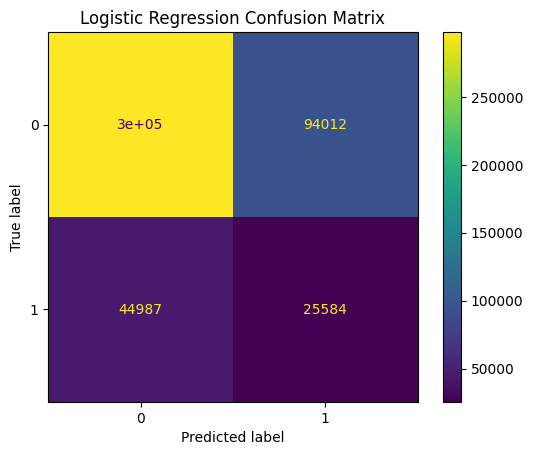

In [123]:
# Logistic Regression confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

logistic_predictions = baseline_model.predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_predictions
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

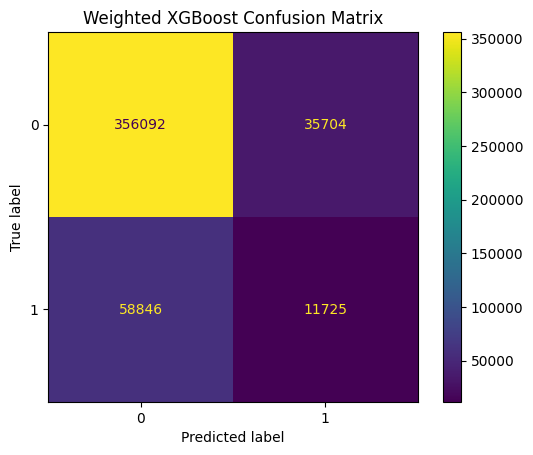

In [124]:
xgb_predictions = xgb_model.predict(X_validation)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    xgb_predictions
)

plt.title("Weighted XGBoost Confusion Matrix")
plt.show()

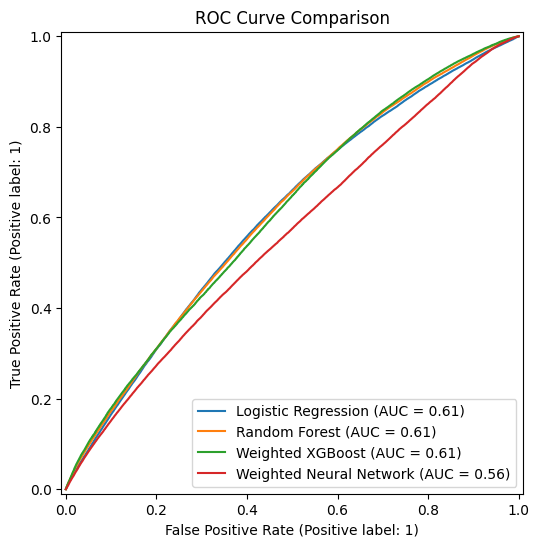

In [125]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Create a figure and an axes object to plot all ROC curves on
fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_estimator(
    baseline_model,
    X_validation,
    y_validation,
    name="Logistic Regression",
    ax=ax # Pass the axes object to the first plot
)

RocCurveDisplay.from_estimator(
    random_forest_model,
    X_validation,
    y_validation,
    name="Random Forest",
    ax=ax # Pass the same axes object to subsequent plots
)

RocCurveDisplay.from_estimator(
    xgb_model,
    X_validation,
    y_validation,
    name="Weighted XGBoost",
    ax=ax # Pass the same axes object
)

RocCurveDisplay.from_estimator(
    weighted_mlp_model,
    X_validation,
    y_validation,
    name="Weighted Neural Network",
    ax=ax # Pass the same axes object
)

plt.title("ROC Curve Comparison")
plt.show()

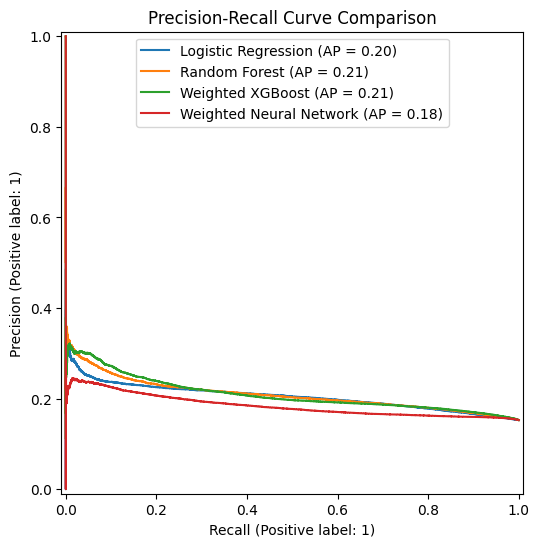

In [126]:
# Create Precision-recall curves
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))


PrecisionRecallDisplay.from_estimator(
    baseline_model,
    X_validation,
    y_validation,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_estimator(
    random_forest_model,
    X_validation,
    y_validation,
    name="Random Forest",
    ax=ax
)

PrecisionRecallDisplay.from_estimator(
    xgb_model,
    X_validation,
    y_validation,
    name="Weighted XGBoost",
    ax=ax
)

PrecisionRecallDisplay.from_estimator(
    weighted_mlp_model,
    X_validation,
    y_validation,
    name="Weighted Neural Network",
    ax=ax
)

plt.title("Precision-Recall Curve Comparison")
ax.legend(loc="upper center")
plt.show()

In [127]:
#Create final comparison model
final_results = pd.DataFrame([
    logistic_results,
    random_forest_results,
    xgb_results,
    weighted_mlp_results
])

final_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.699,0.214,0.363,0.269,0.606,0.204
1,Random Forest,0.821,0.260,0.093,0.136,0.609,0.209
2,XGBoost,0.796,0.247,0.166,0.199,0.607,0.209
3,Neural Network (w),0.825,0.234,0.064,0.100,0.560,0.184


Model Explanation:

Logistic Regression achieved the highest recall (0.363) and F1-score (0.269), making it the strongest model for identifying delayed flights. Random Forest achieved higher accuracy and precision but detected fewer delayed flights. The weighted XGBoost model improved detection of delayed flights compared with the unweighted version by addressing class imbalance, although its recall remained lower than Logistic Regression. The weighted Neural Network applied balanced sample weights which allowed the NN to identify some delayed flights but its recall and F1 score remained low. Because the goal was to identify potential delays rather then maximizing accuracy, logistic regression was selected as the final model.


# Final December test

In [128]:
logistic_test_results = evaluate_model("Logistic Regression - December Test", baseline_model, X_test, y_test)
logistic_test_results

{'Model': 'Logistic Regression - December Test',
 'Accuracy': 0.6818871788757912,
 'Precision': 0.24839193722581693,
 'Recall': 0.26855908733931305,
 'F1': 0.2580821346467992,
 'ROC_AUC': 0.5750337828649821,
 'PR_AUC': 0.24239827439120398}

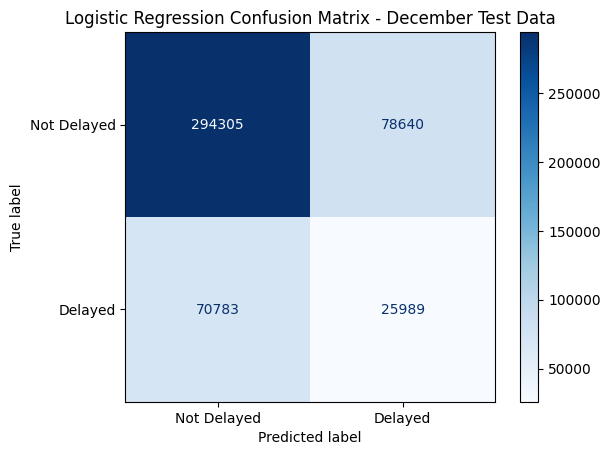

In [129]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(baseline_model, X_test, y_test, display_labels=["Not Delayed", "Delayed"], cmap="Blues")
plt.title("Logistic Regression Confusion Matrix - December Test Data")
plt.show()

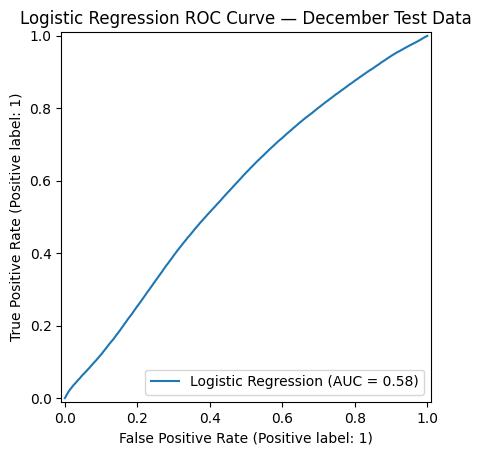

In [130]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test,
    name="Logistic Regression" )

plt.title("Logistic Regression ROC Curve — December Test Data")
plt.show()

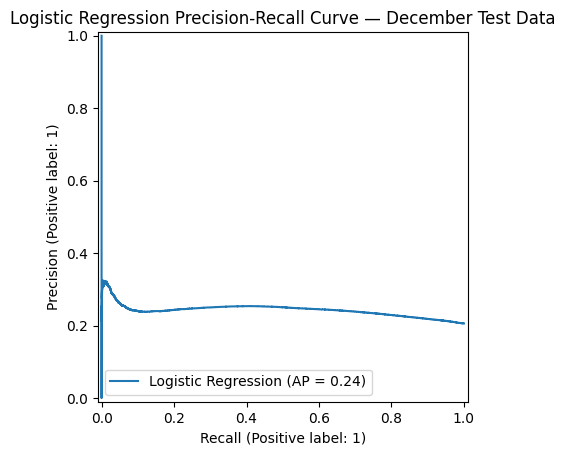

In [131]:
PrecisionRecallDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

plt.title("Logistic Regression Precision-Recall Curve — December Test Data")
plt.show()

In [132]:
final_test_results_dec_test = pd.DataFrame([
    evaluate_model("Logistic Regression", baseline_model, X_test, y_test),
    evaluate_model("Random Forest", random_forest_model, X_test,y_test),
    evaluate_model("XGBoost", xgb_model, X_test, y_test ),
    evaluate_model( "Neural Network (w)",weighted_mlp_model,X_test, y_test)
])

display(final_test_results_dec_test.round(3))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.682,0.248,0.269,0.258,0.575,0.242
1,Random Forest,0.761,0.260,0.086,0.130,0.579,0.246
2,XGBoost,0.721,0.249,0.176,0.206,0.584,0.248
3,Neural Network (w),0.784,0.305,0.036,0.064,0.558,0.242


GenAI was used to help code error, organiziing visulizations to be easier to interpret and improve code readability

In [133]:
%%capture --no-display
!apt-get update -qq > /dev/null 2>&1
!DEBIAN_FRONTEND=noninteractive apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc > /dev/null 2>&1

In [134]:
!jupyter nbconvert \
    --to pdf \
    "/content/drive/MyDrive/Colab Notebooks/ADS504Project.ipynb" \
    --output-dir="/content"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/ADS504Project.ipynb to pdf
[NbConvertApp] Support files will be in ADS504Project_files/
[NbConvertApp] Making directory ./ADS504Project_files
[NbConvertApp] Writing 285797 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 768607 bytes to /content/ADS504Project.pdf
